In [46]:
import pandas as pd
import os
import pickle as pkl
import numpy as np
from pathlib import Path
from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats
import random
from bioinfokit import analys, visuz
import matplotlib.pyplot as plt

OUTPUT_PATH = Path("../outputs/output_files_cdk4-mdm2")
os.makedirs(OUTPUT_PATH, exist_ok=True)

In [47]:
# 1. import event matrix and filter to samples with bulk RNA data
included_samples = pd.read_csv("../../SV/SV_sample_data/data/final_analysis_samples.csv")
included_cohorts = ['StJude', 'TARGET', 'DFCI_with_snRNAseq']
included_samples = included_samples[included_samples['cohort'].isin(included_cohorts)]
events_df = pd.read_csv("../../SV/SV_signature_analysis/Clustered_SVs/results/clustered_sv_merged_hotspot_matrix.csv")
events_df = events_df[events_df['sample_id'].isin(included_samples['tumor_normal_pair'])]
events_df

,sample_id,CCND3,MYC,CDK4-MDM2,CCNE1,TP53,n_clustered_regions
4,17_439_00067_T2-17_439_00067_WB,0,0,0,0,0,3
5,17_439_00097_T1-17_439_00097_WB,0,0,0,0,0,0
6,CCG1106_005_T1-CCG1106_005_WB,0,0,0,0,1,12
7,CCG1106_074_T1-CCG1106_074_WB,0,0,0,0,0,1
8,CCG1106_075_T1-CCG1106_075_WB,0,0,0,0,1,3
...,...,...,...,...,...,...,...
225,TARGET-40-PASSLM-01A-TARGET-40-PASSLM-10A,0,0,0,0,0,0
226,TARGET-40-PASUUH-01A-TARGET-40-PASUUH-10A,0,0,0,1,1,5
227,TARGET-40-PATAWV-01A-TARGET-40-PATAWV-10A,0,0,0,0,0,1
228,TARGET-40-PATMPU-01A-TARGET-40-PATMPU-10A,1,0,0,1,0,8


In [48]:
# 2. import counts matrices
counts_df_stjude = pd.read_csv("../data/expression-data_bulk-rna_sjc-os-same-sample-counts-matrix.tsv", sep="\t", index_col=0)
counts_df_target = pd.read_csv("../data/expression-data_bulk-rna_target-os-counts-matrix.tsv", sep="\t", index_col=0)
counts_df_dfci = pd.read_csv("../data/expression-data_bulk-rna_dfci-internal-rsem-count-matrix.tsv", sep="\t")
counts_df_dfci = counts_df_dfci.iloc[:, 1:]
counts_df_dfci.index = counts_df_dfci.iloc[:, 0]
counts_df_dfci = counts_df_dfci.iloc[:, 1:]
counts_df_dfci = counts_df_dfci.groupby(counts_df_dfci.index).sum()

# ‘number of samples’ x ‘number of genes’
counts_df_stjude = counts_df_stjude.T
counts_df_target = counts_df_target.T
counts_df_dfci = counts_df_dfci.T
counts_df_stjude = counts_df_stjude.drop(['__no_feature', '__ambiguous', '__too_low_aQual', '__not_aligned', '__alignment_not_unique'], axis=1)

# concatenate counts matrics, add cohort column, only keep genes common to all cohorts
common_genes = (
    counts_df_stjude.columns
    .intersection(counts_df_target.columns)
    .intersection(counts_df_dfci.columns)
)
common_genes = sorted(common_genes)

counts_st = counts_df_stjude[common_genes].copy()
counts_tg = counts_df_target[common_genes].copy()
counts_dfci = counts_df_dfci[common_genes].copy()

counts_st = counts_st.apply(pd.to_numeric, errors="coerce").fillna(0).astype(int)
counts_tg = counts_tg.apply(pd.to_numeric, errors="coerce").fillna(0).astype(int)
counts_dfci = counts_dfci.apply(pd.to_numeric, errors="coerce").fillna(0).astype(int)

counts_df = pd.concat([counts_st, counts_tg, counts_dfci], axis=0)  # stack samples

# filter to included samples
pairs = included_samples["tumor_normal_pair"].dropna().astype(str)
def sample_in_any_pair(s):
    s = str(s)
    return pairs.str.startswith(s + "-", na=False).any()
keep = counts_df.index.to_series().map(sample_in_any_pair)
counts_df = counts_df.loc[keep]

n_st_filtered = counts_df.index.isin(counts_st.index).sum()
n_tg_filtered = counts_df.index.isin(counts_tg.index).sum()
n_dfci_filtered = counts_df.index.isin(counts_dfci.index).sum()
print(f"Filtered St Jude samples: {n_st_filtered}, Filtered TARGET samples: {n_tg_filtered}, Filtered DFCI samples: {n_dfci_filtered}")
print(f"Genes (common to both): {len(common_genes)}")

Filtered St Jude samples: 65, Filtered TARGET samples: 33, Filtered DFCI samples: 8
Genes (common to both): 32011


In [49]:
# 3. filter to common sample set and create metadata dataframe
# Build condition metadata from events_df
metadata = events_df[['sample_id', 'CDK4-MDM2']].copy()
metadata = metadata.rename(columns={'CDK4-MDM2': 'condition'})
metadata['condition'] = metadata['condition'].replace({
    0: 'no_sv_cluster',
    1: 'sv_cluster'
})
counts_ids = counts_df.index.astype(str).tolist()
metadata = metadata[
    metadata['sample_id'].astype(str).apply(
        lambda full_id: any(str(full_id).startswith(c + "-") for c in counts_ids)
    )
].copy()
metadata['sample_short'] = metadata['sample_id'].astype(str).apply(
    lambda full_id: next((c for c in counts_ids if str(full_id).startswith(c + "-")), np.nan)
)
metadata = metadata.dropna(subset=['sample_short']).drop_duplicates(subset=['sample_short'])

st_idx = set(counts_st.index.astype(str))
tg_idx = set(counts_tg.index.astype(str))
dfci_idx = set(counts_dfci.index.astype(str))
metadata['cohort'] = metadata['sample_short'].astype(str).map(
  lambda s: 'StJude' if s in st_idx else ('TARGET' if s in tg_idx else ('DFCI' if s in dfci_idx else np.nan))
)

metadata = metadata.set_index('sample_short')

# Reorder metadata to match counts_df row order
metadata = metadata.loc[counts_df.index]

print(f"Counts samples kept: {len(counts_df)}")
print(metadata['condition'].value_counts())
print(metadata['cohort'].value_counts())
metadata.head()

Counts samples kept: 106
condition
no_sv_cluster    96
sv_cluster       10
Name: count, dtype: int64
cohort
StJude    65
TARGET    33
DFCI       8
Name: count, dtype: int64


,sample_id,condition,cohort
SJST032337_D1,SJST032337_D1-SJST032337_G1,no_sv_cluster,StJude
SJOS063824_D1,SJOS063824_D1-SJOS063824_G1,no_sv_cluster,StJude
SJOS071781_D1,SJOS071781_D1-SJOS071781_G1,no_sv_cluster,StJude
SJOS033930_D1,SJOS033930_D1-SJOS033930_G1,no_sv_cluster,StJude
SJOS013_D,SJOS013_D-SJOS013_H,no_sv_cluster,StJude


In [50]:
# 4. data filtering
genes_to_keep = counts_df.columns[counts_df.sum(axis=0) >= 10]
counts_df = counts_df[genes_to_keep]

In [51]:
# 5. create a DeseqDataSet object
inference = DefaultInference(n_cpus=8)
dds = DeseqDataSet(
    counts=counts_df,
    metadata=metadata,
    design="~cohort + condition",  # compare samples based on the "condition" and cohort as a covariate
    refit_cooks=True,
    inference=inference,
)

In [52]:
#6. fits dispersions and LFCs
dds.deseq2()
print(dds)
with open(os.path.join(OUTPUT_PATH, "result_w_dfci_adata.pkl"), "wb") as f:
    pkl.dump(dds.to_picklable_anndata(), f)

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.08 seconds.

Fitting dispersions...
... done in 2.83 seconds.

Fitting dispersion trend curve...
... done in 0.30 seconds.

Fitting MAP dispersions...
... done in 2.90 seconds.

Fitting LFCs...
... done in 3.06 seconds.

Calculating cook's distance...
... done in 0.12 seconds.

Replacing 3286 outlier genes.

Fitting dispersions...
... done in 0.37 seconds.

Fitting MAP dispersions...
... done in 0.35 seconds.

Fitting LFCs...


AnnData object with n_obs × n_vars = 106 × 31429
    obs: 'sample_id', 'condition', 'cohort', 'size_factors', 'replaceable'
    var: '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', '_LFC_converged', 'replaced', 'refitted', '_pvalue_cooks_outlier'
    uns: 'trend_coeffs', 'disp_function_type', '_squared_logres', 'prior_disp_var'
    obsm: 'design_matrix', '_mu_LFC', '_hat_diagonals'
    varm: 'LFC'
    layers: 'normed_counts', '_mu_hat', 'cooks', 'replace_cooks'


... done in 0.42 seconds.



In [53]:
# 7. statistical analysis
ds = DeseqStats(dds, contrast=["condition", "sv_cluster", "no_sv_cluster"], inference=inference)
ds.summary()

Running Wald tests...


Log2 fold change & Wald test p-value: condition sv_cluster vs no_sv_cluster
                  baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene_name                                                                  
A1BG             29.630802       -0.188037  0.469058 -0.400883  0.688507   
A1BG-AS1        130.412613        0.093499  0.397281  0.235346  0.813940   
A1CF              5.219597       -0.361362  0.852051 -0.424109  0.671486   
A2M           38904.726521        0.173027  0.296817  0.582942  0.559932   
A2M-AS1         111.841603        0.426553  0.430190  0.991546  0.321419   
...                    ...             ...       ...       ...       ...   
ZYG11A           97.923866       -0.437739  0.690499 -0.633946  0.526116   
ZYG11B         2294.806933       -0.478450  0.233554 -2.048565  0.040505   
ZYX            3358.765774        0.328344  0.265993  1.234411  0.217050   
ZZEF1          2734.566506        0.017346  0.204055  0.085005  0.932257   
hsa-mir-1253

... done in 0.63 seconds.



In [54]:
ds.results_df.to_csv(os.path.join(OUTPUT_PATH, "results_w_dfci.csv"))
sig_results_df = ds.results_df[(ds.results_df['padj'] < 0.05) & (ds.results_df['log2FoldChange'].abs() > 1)]
sig_results_df.to_csv(os.path.join(OUTPUT_PATH, "sig_results_w_dfci.csv"))

In [55]:
# where are the significantly upregulated/downregulated genes? Are they in the same region as the clustered SV event? 

# import file with gene coordinates
gene_allelic_file = pd.read_csv("../data/gene_coordinates.txt", sep="\t")

# Clean, map, and filter to 1-24
gene_allelic_file ['Chromosome/scaffold name'] = (
    gene_allelic_file['Chromosome/scaffold name']
    .replace({'X': '23', 'Y': '24'})
)

gene_allelic_file['Chromosome/scaffold name'] = pd.to_numeric(gene_allelic_file['Chromosome/scaffold name'])
gene_allelic_file = gene_allelic_file[(gene_allelic_file ['Chromosome/scaffold name'] >= 1) & (gene_allelic_file['Chromosome/scaffold name'] <= 24)]
gene_allelic_file['Chromosome/scaffold name'] = gene_allelic_file['Chromosome/scaffold name'].astype(int)
gene_allelic_file['Chromosome/scaffold name'].value_counts()

Chromosome/scaffold name
1     7090
2     5686
6     4230
11    4166
3     4158
7     3957
5     3946
12    3860
17    3780
4     3577
19    3545
10    3268
8     3265
16    3188
9     3188
23    2958
15    2818
14    2797
13    2001
20    1970
22    1747
18    1653
21    1134
24     672
Name: count, dtype: int64

Genes to plot: 543
  Upregulated: 325
  Downregulated: 218


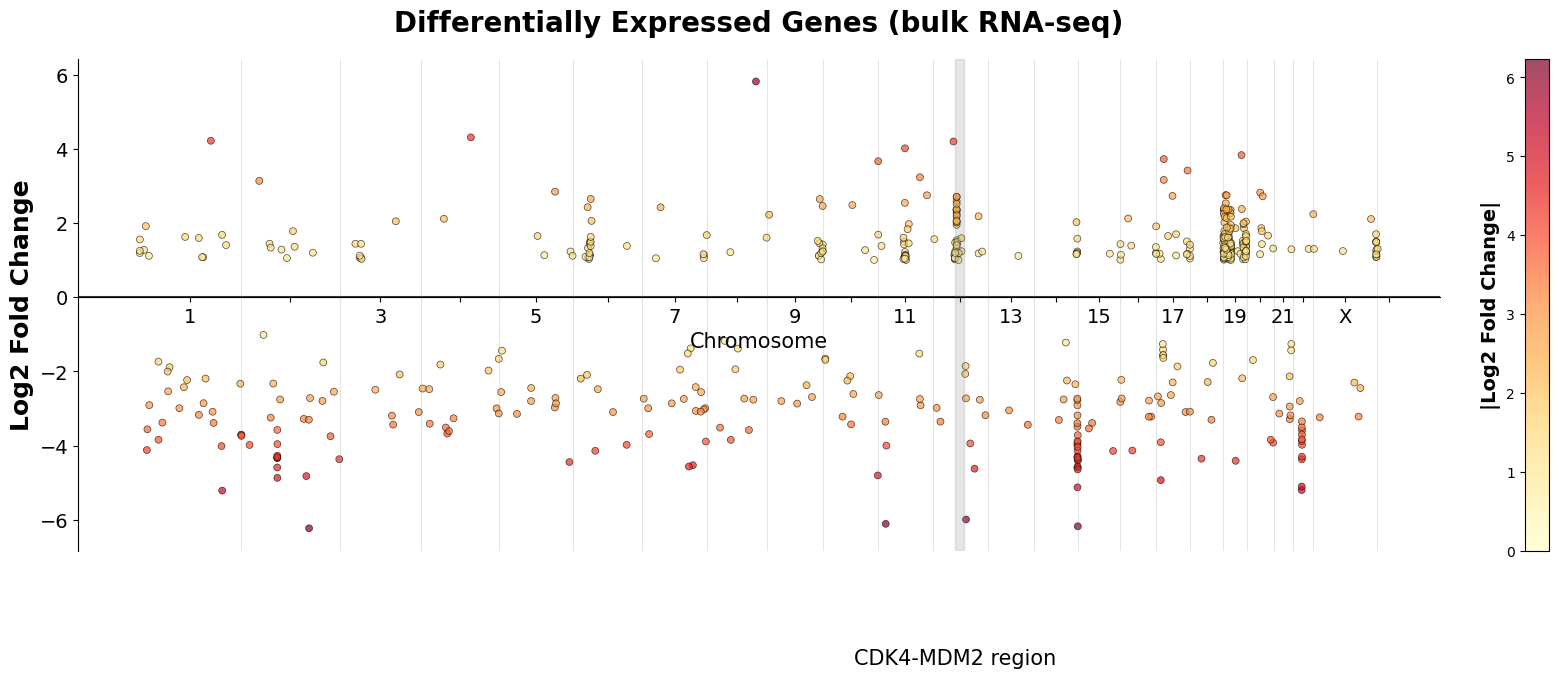

Exception ignored in: <function ResourceTracker.__del__ at 0x105bc1bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x107161bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10a4c1bc0>
Traceback (most recent call last

In [ ]:
# map significant degs to their coordinates
sig_results_with_coords = sig_results_df.reset_index().merge(
    gene_allelic_file, 
    left_on='gene_name', 
    right_on='Gene name', 
    how='left'
)

region_of_interest = {"chrom": 12, "start": 53000000, "end": 75000000}
# find sig genes in regions of interest and add to annotation to sig_results_with_coords
sig_results_with_coords['in_region'] = sig_results_with_coords.apply(
    lambda row: 'yes' if row['Chromosome/scaffold name'] == region_of_interest['chrom'] and 
    row['Gene start (bp)'] >= region_of_interest['start'] and 
    row['Gene end (bp)'] <= region_of_interest['end'] else 'no', axis=1
)

sig_results_with_coords.to_csv(os.path.join(OUTPUT_PATH, "sig_results_w_dfci.csv"))

sig_genes = sig_results_with_coords[sig_results_with_coords['Chromosome/scaffold name'].notna()].copy()

sig_genes = sig_genes[(sig_genes['Chromosome/scaffold name'] >= 1) & 
                       (sig_genes['Chromosome/scaffold name'] <= 24)]

print(f"Genes to plot: {len(sig_genes)}")
print(f"  Upregulated: {(sig_genes['log2FoldChange'] > 0).sum()}")
print(f"  Downregulated: {(sig_genes['log2FoldChange'] < 0).sum()}")

# Manhattan-style plot
fig, ax = plt.subplots(figsize=(18, 7))

all_chroms = list(range(1, 25))
chromosome_lengths = {}
cumulative_pos = 0
chrom_centers = {}

# Calc cumulative positions for all chromosomes
for chrom in all_chroms:
    chrom_lengths_dict = {1: 248956422, 2: 242193529, 3: 198295559, 4: 190214555,
                             5: 181538259, 6: 170805979, 7: 159345973, 8: 145138636,
                             9: 138394717, 10: 133797422, 11: 135086622, 12: 133275309,
                             13: 114364328, 14: 107043718, 15: 101991189, 16: 90338345,
                             17: 83257441, 18: 80373285, 19: 58617616, 20: 64444167,
                             21: 46709983, 22: 50818468, 23: 156040895, 24: 57227415}

    max_pos = chrom_lengths_dict.get(chrom)
    
    chromosome_lengths[chrom] = max_pos
    chrom_centers[chrom] = cumulative_pos + max_pos / 2
    
    # Add cumulative position for genes on this chromosome
    if chrom in sig_genes['Chromosome/scaffold name'].values:
        sig_genes.loc[sig_genes['Chromosome/scaffold name'] == chrom, 'cumulative_pos'] = \
            sig_genes.loc[sig_genes['Chromosome/scaffold name'] == chrom, 'Gene start (bp)'] + cumulative_pos
    
    cumulative_pos += max_pos

# Calculate absolute fold change for coloring
sig_genes['abs_log2FC'] = sig_genes['log2FoldChange'].abs()

# Add gray shaded area for region of interest
cumulative_offset = sum([chromosome_lengths[c] for c in range(1, region_of_interest['chrom'])])
region_cumulative_start = cumulative_offset + region_of_interest['start']
region_cumulative_end = cumulative_offset + region_of_interest['end']

ax.axvspan(region_cumulative_start, region_cumulative_end, alpha=0.2, color='gray', zorder=2)
# add label to the region of interest
ax.text(region_cumulative_start+3, -10, 'CDK4-MDM2 region', fontsize=15, ha='center', va='bottom', color='black')

# Create scatter plot colored by absolute fold change magnitude
scatter = ax.scatter(
    sig_genes['cumulative_pos'],
    sig_genes['log2FoldChange'],
    c=sig_genes['abs_log2FC'],
    s=25,
    alpha=0.7,
    cmap='YlOrRd',
    edgecolors='black',
    linewidth=0.5,
    vmin=0,
    vmax=sig_genes['abs_log2FC'].max()
)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('|Log2 Fold Change|', fontsize=14, fontweight='bold')
# move colorbar closer to the plot
cbar.ax.yaxis.set_ticks_position('left')
cbar.ax.yaxis.set_label_position('left')

# Add horizontal line at y=0
ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5, alpha=0.8, zorder=1)

# Add vertical lines to separate chromosomes
cumulative_pos = 0
for i, chrom in enumerate(all_chroms):
    if i > 0:
        ax.axvline(cumulative_pos, color='gray', linestyle='-', alpha=0.3, linewidth=0.5)
    cumulative_pos += chromosome_lengths[chrom]

ax.set_xlabel('Chromosome', fontsize=15)
ax.set_ylabel('Log2 Fold Change', fontsize=18, fontweight='bold')
ax.set_title('Differentially Expressed Genes (bulk RNA-seq)', 
             fontsize=20, fontweight='bold', pad=20)

# Set chromosome labels at x-axis (y=0)
ax.set_xticks([chrom_centers[c] for c in all_chroms])
chrom_labels = [str(c) if c <= 22 else ('X' if c == 23 else 'Y') for c in all_chroms]
# Show only every other label
chrom_labels = [label if i % 2 == 0 else '' for i, label in enumerate(chrom_labels)]
ax.set_xticklabels(chrom_labels, rotation=0, fontsize=16)
# change size of y-axis ticks
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x', labelsize=14)
# Move x-axis to y=0
ax.spines['bottom'].set_position('zero')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

#ax.grid(axis='y', alpha=0.3, linestyle='--', zorder=0)

plt.tight_layout()
#plt.savefig(os.path.join(OUTPUT_PATH, 'all_sig_genes_manhattan.png'), dpi=300, bbox_inches='tight')
plt.show()